# RAW EEG Temporal analysis: MDD VS Healthy Controls

This notebook documents the exploratory workflow used to compare depression-related EEG structure across patients. 

The goal is not only to train a classifier, but to understand which EEG representation is most useful:

1. Segment raw EEG recordings into fixed-length time windows. 
2. Extract Welch band-power features from each segment for temporal ablation. 
3. Evaluate classical ML models using patient-level GroupKFold. 
4. Explore temporal ablation to test whether specific time windows are especially important.
5. Compare Welch feautures against raw-signal models, including CNN-based approaches. 


## 1. Imports and Configuration 

In [4]:
import os 
from pathlib import Path 
from collections import Counter 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
)

import umap
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam


In [6]:
# Reproducibility 
RANDOM_STATE = 42
N_SPLITS = 5

# Set to True onlu when you want to rerun the expensive TensorFlow models.
RUN_DEEP_MODELS = False

# EEG channels standardized across recordings
COMMON_CHANNELS = [
'EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE',
 'EEG F7-LE', 'EEG T3-LE', 'EEG T5-LE', 'EEG Fz-LE', 'EEG Fp2-LE', 
 'EEG F4-LE', 'EEG C4-LE', 'EEG P4-LE', 'EEG O2-LE', 'EEG F8-LE', 
 'EEG T4-LE', 'EEG T6-LE', 'EEG Cz-LE', 'EEG Pz-LE', 'EEG A2-A1'
]

# Frequency bands used for Welch band-power features 

BANDS = {
    'delta': (1,4),
    'theta': (4,3),
    'alpha': (8,13),
    'beta': (13,30)
}

In [7]:
def find_project_root():
    """ Find the project root by walking upward until a .git folder is found."""
    p = Path.cwd()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    raise FileNotFoundError("Project root (with .git) not found")

PROJECT_ROOT = find_project_root()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "nm000114"
RESULTS_DIR = PROJECT_ROOT / "results"
SEGMENTED_DATA_DIR = PROJECT_ROOT / "data" / "segmented_data"

SEGMENTED_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DATA_DIR:", RAW_DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("SEGMENTED_DATA_DIR:", SEGMENTED_DATA_DIR)

PROJECT_ROOT: d:\eeg-mdd-classification
RAW_DATA_DIR: d:\eeg-mdd-classification\data\raw\nm000114
RESULTS_DIR: d:\eeg-mdd-classification\results
SEGMENTED_DATA_DIR: d:\eeg-mdd-classification\data\segmented_data


## 2. Build Recording Metadata 

Each EDF file is mapped to patient ID, recording ID, diagnostic label, condition, and filepath. 

Labels:

- 0 = healthy control 
- 1 = MDD 

This metadata table is important becuase cross-validation will be grouped by patient_id to prevent patient leakage. 

In [8]:
def infer_label_from_subject(subject_id: str) -> int:
    """
    Infer the label (0 for healthy control, 1 for MDD) from the subject ID.
    """
    subject_upper = subject_id.upper()
    if "HS" in subject_upper:
        return 0
    elif "MDD" in subject_upper:
        return 1 
    else: 
        raise ValueError(f"Could not infer label from subject ID: {subject_id}")
    
def parse_condition_from_filename(filepath: Path) -> str:
    """
    Parse the condition (eyesClosed, eyesOpen, P300) from the filename.
    """
    name = filepath.name 
    if "task-eyesClosed" in name:
        return "eyesClosed"
    elif "task-eyesOpen" in name:
        return "eyesOpen"
    elif "task-P300" in name:
        return "P300"
    else:
        raise ValueError(f"Could not parse condition from filename: {name}")
        
edf_files =sorted(RAW_DATA_DIR.glob("sub*/eeg/*.edf"))
        
rows = []
for filepath in edf_files:
    subject_id = filepath.parts[-3] 
    rows.append({
        "patient_id": subject_id,
        "recording_id": filepath.stem,
        "label": infer_label_from_subject(subject_id),
        "condition": parse_condition_from_filename(filepath),
        "filepath": str(filepath),
    })


# Create a DataFrame from the metadata
metadata_df = pd.DataFrame(rows)
metadata_df.head()        

,patient_id,recording_id,label,condition,filepath
0,sub-HS1,sub-HS1_task-eyesClosed_eeg,0,eyesClosed,d:\eeg-mdd-classification\data\raw\nm000114\su...
1,sub-HS1,sub-HS1_task-eyesOpen_eeg,0,eyesOpen,d:\eeg-mdd-classification\data\raw\nm000114\su...
2,sub-HS1,sub-HS1_task-P300_eeg,0,P300,d:\eeg-mdd-classification\data\raw\nm000114\su...
3,sub-HS10,sub-HS10_task-eyesClosed_eeg,0,eyesClosed,d:\eeg-mdd-classification\data\raw\nm000114\su...
4,sub-HS10,sub-HS10_task-eyesOpen_eeg,0,eyesOpen,d:\eeg-mdd-classification\data\raw\nm000114\su...


In [9]:
print("Shape:", metadata_df.shape)
print("\nUnique patients:", metadata_df["patient_id"].nunique())
print("\nClass counts:")
print(metadata_df["label"].value_counts())
print("\nCondition counts:")
print(metadata_df["condition"].value_counts())


Shape: (181, 5)

Unique patients: 64

Class counts:
label
1    95
0    86
Name: count, dtype: int64

Condition counts:
condition
eyesOpen      62
P300          61
eyesClosed    58
Name: count, dtype: int64


## 3. Exploratory Segmentation Check 

Before building the full dataset, test segmentation on one recording. This confirms that the EDF files loads correctly, the common EEG channels are present, and fixed-length windows are created as expected. 

In [10]:
test_path = metadata_df.loc[0,"filepath"]


raw_test = mne.io.read_raw_edf(test_path, preload=True, verbose=False) 
raw_test.pick(COMMON_CHANNELS)

# create 5-second windows 
epochs_test = mne.make_fixed_length_epochs(
    raw_test,
    duration=5.0,
    preload=True,
    overlap=0.0
)

print("Raw test data shape:", raw_test.get_data().shape)
print("Epoch test data shape:", epochs_test.get_data().shape)
print("Sampling frequency:", raw_test.info["sfreq"])

Not setting metadata
60 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 60 events and 1280 original time points ...
0 bad epochs dropped
Raw test data shape: (20, 76800)
Epoch test data shape: (60, 20, 1280)
Sampling frequency: 256.0


- 150 windows, recording was split into 150 chunkcs of 2 seconds each 
- 20 channels: matches standardized EEG channels
- 512 timepoints: confirms sampling rate ~256 Hz
- 1 recording -> 150 samples 

- very short time windows do not provide sufficient frequency resolution for stable band-power features

changed to chunks of 5 seconds 
- 60 windows- fewer because they are longer
- 20 channels
- 1280 timepoints



This exploratory check motivated the final segmentation approach:

- Each recording can be split into fixed-length windows.
- The channel dimension is standardized to the same 20 common EEG channels.
- A short window size can create many samples, but very short windows may cause issues for Welch PSD estimation. 

## 4. Welch Band-Power Feature Extraction 

For each EEG segment, Welch's method estimates power spectral density from 1-30 Hz. The final feature vector has:

20 channels x 4 frequency bands = 80 features 

Band-power features are normalized by total power to reduce differences caused by overall signal amplitude. 

In [11]:
def extract_band_power_from_array(epoch_data, sfreq):
    """ 
    Extract relative Welch band-power features from one EEG window.

    Parameters
    ---------
    epoch_data: np.darray
        Shape: (n_channels, n_timepoints)
    sfreq: float
        Sampling frequency. 
    bands: dict 
        Frequency-band definitions. 

    Returns
    -------
    np.ndarray
      Flatten feature vector with shape (n_channels * n_bands,).
    """

    bands = {
        "delta": (1, 4),     # deep sleep
        "theta": (4, 8),     # drowsiness
        "alpha": (8, 13),    # relaxed 
        "beta":  (13, 30)    # active thinking
    }

    all_features = []

    for ch in epoch_data:
        psd, freqs = mne.time_frequency.psd_array_welch(
            ch,
            sfreq=sfreq,
            fmin=1,
            fmax=30,
            n_fft=min(len(ch), 256),   # use smaller n_fft for short windows
            n_per_seg=min(len(ch), 256),
            verbose=False
        )

        total_power = psd.sum()

        band_features = [
            (
                psd[(freqs >= fmin) & (freqs <= fmax)].mean() / total_power
                if total_power > 0 else 0 
            )
            for (fmin, fmax) in bands.values()
        ]

        all_features.append(band_features)

    return np.nan_to_num(np.array(all_features).flatten())

# sanity check on one epoch 
epoch_array = epochs_test.get_data()[0]
features_test = extract_band_power_from_array(epoch_array, epochs_test.info['sfreq'])

print("Feature vector shape:", features_test.shape)

Feature vector shape: (80,)


## 5. Build and Cache Segmented Welch Datasets 

The full dataset is expensive to rebuild, so the final helper functions save and reload segmented arrays. 

Each returned dataset contains: 

- X_seg: Welch feature matrix
- y_seg: binary diagnostic labels
- groups_seg: patients IDs for grouped cross-validation
- seg_df: metadata for each segment, including segment_idx

In [12]:
def build_segmented_dataset(metadata_df, common_channels, window_sec):
    """ Build segmented Welch band-power features from all EDF recordings."""
    X_segments = []
    y_segments = []
    groups_segments = []
    condition_segments = []
    recording_segments = []
    segmented_indices = []

    for _, row in metadata_df.iterrows():
        raw = mne.io.read_raw_edf(row["filepath"], preload=True, verbose=False)
        raw.pick(common_channels)

        epochs = mne.make_fixed_length_epochs(
            raw,
            duration=window_sec,
            preload=True,
            overlap=0.0,
            verbose=False
        )

        epoch_data = epochs.get_data()
        sfreq = epochs.info["sfreq"]

        for i in range(len(epoch_data)):
            features = extract_band_power_from_array(epoch_data[i], sfreq)

            X_segments.append(features)
            y_segments.append(row["label"])
            groups_segments.append(row["patient_id"])
            condition_segments.append(row["condition"])
            recording_segments.append(f"{row['recording_id']}_seg{i}")
            segmented_indices.append(i)

    X_segments = np.vstack(X_segments)
    y_segments = np.array(y_segments)
    groups_segments = np.array(groups_segments)

    segmented_df = pd.DataFrame({
        "recording_segment": recording_segments,
        "petient_id": groups_segments,
        "label": y_segments,
        "condition": condition_segments,
        "segment_idx": segmented_indices
    })

    return X_segments, y_segments, groups_segments, segmented_df

def save_segmented_data(X, y, groups, seg_df, window_sec, save_dir=SEGMENTED_DATA_DIR):
    """ Save segmented arrays and metadata to disk"""
    save_dir.mkdir(parents=True, exist_ok=True)

    suffix = f"{int(window_sec)}sec"

    np.save(save_dir / f"X_seg_{suffix}.npy", X)
    np.save(save_dir / f"y_seg_{suffix}.npy", y)
    np.save(save_dir / f"groups_seg_{suffix}.npy", groups)
    seg_df.to_csv(save_dir / f"seg_df_{suffix}.csv", index=False)

def load_segmented_data(window_sec, save_dir=SEGMENTED_DATA_DIR):
    """ Load segmented arrys and metadata from disk."""
    suffix = f"{int(window_sec)}sec"

    X = np.load(save_dir /  f"X_seg_{suffix}.npy")
    y = np.load(save_dir / f"y_seg_{suffix}.npy")
    groups = np.load(save_dir / f"groups_seg_{suffix}.npy")
    seg_df = pd.read_csv(save_dir / f"seg_df_{suffix}.csv")

    return X, y, groups, seg_df


def get_or_build_segmented_data(metadata_df, common_channels, window_sec, save_dir=SEGMENTED_DATA_DIR):
    """ Load cached segmented data if available; otherwise build and save it."""
    suffix = f"{int(window_sec)}sec"
    X_path = save_dir / f"X_seg_{suffix}.npy"

    if X_path.exists():
        print(f"loading cached data for {window_sec}s...")
        return load_segmented_data(window_sec, save_dir=save_dir)
    
    print(f"Building segmented data for {window_sec}s...")
    X, y, groups, seg_df = build_segmented_dataset(
        metadata_df, 
        common_channels,
        window_sec=window_sec
    )

    save_segmented_data(X, y, groups, seg_df, window_sec)

    return X, y, groups, seg_df 

In [13]:
# Final feature datasets used in the main analysis
X_seg_5, y_seg_5, groups_seg_5, seg_df_5 = build_segmented_dataset(
    metadata_df,
    COMMON_CHANNELS,
    window_sec=5.0
)

X_seg_10, y_seg_10, groups_seg_10, seg_df_10 = build_segmented_dataset(
    metadata_df,
    COMMON_CHANNELS,
    window_sec=10.0
)

print("5-sec Welch feature shape:", X_seg_5.shape)
print("10-sec Welch feature shape:", X_seg_10.shape)
print("Unique patients:", pd.Series(groups_seg_10).nunique())

5-sec Welch feature shape: (14743, 80)
10-sec Welch feature shape: (7339, 80)
Unique patients: 64


## 6. Classical Model Evaluation 

The primary classical model is an SVM with an RBF kernel. Logistic regression is included as a simpler baseline. 

Important design choice: GroupKFold is grouped by patient ID. This prevents EEG windows from the same patient appearing in both train and test folds. 

In [22]:
gkf = GroupKFold(n_splits=N_SPLITS)

models = {
    "LogisticRegression": Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
]),
    "SVM RBF":  Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, random_state=42))
])
}

def evaluate_sklearn_model(model, X, y, groups, cv=gkf):
    """ Evaluate a scikit-learn model using grouped cross-validation."""
    scores = cross_validate(
        model, 
        X,
        y, 
        groups=groups,
        cv=cv,
        scoring=["accuracy", "f1", "roc_auc"]
    )

    return {
        "accuracy": scores["test_accuracy"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc-auc": scores["test_roc_auc"].mean()
    }

In [41]:
window_results = []

for window_sec, X, y, groups in [
    (5.0, X_seg_5, y_seg_5, groups_seg_5),
    (10.0, X_seg_10, y_seg_10, groups_seg_10)
]:
    svm_scores = evaluate_sklearn_model(models["SVM RBF"], X, y, groups)
    window_results.append({
        "window_sec": window_sec,
        **svm_scores
    })

window_results_df = pd.DataFrame(window_results)
window_results_df 

,window_sec,accuracy,f1,roc-auc
0,5.0,0.798763,0.812561,0.889488
1,10.0,0.827231,0.844465,0.908115


### Interpretation:
The 10-sec windows performed better than the 5-second windows in the exploratory comparison. This suggests that depression-related spectral structure may be more stable when the model sees a slighlty longer EEG segment. 

In [39]:
classical_results = []

for model_name, model in models.items():
    scores = evaluate_sklearn_model(model, X_seg_10, y_seg_10, groups_seg_10)
    classical_results.append({
        "method": f"Welch + {model_name} (10 sec)",
        **scores 
    })

classical_results_df = pd.DataFrame(classical_results)
classical_results_df 

,method,accuracy,f1,roc-auc
0,Welch + LogisticRegression (10 sec),0.801850,0.810668,0.884826
1,Welch + SVM RBF (10 sec),0.827231,0.844465,0.908115


 ## 7. Temporal Ablation  

The next exploratory questions is:

Are certian time segments more important than others?

To test this, one segment index is removed at a time, and the SVM is re-evaluated. If removing a specific segment causes a large performance drop, that part of the recording may contain especially useful signal.

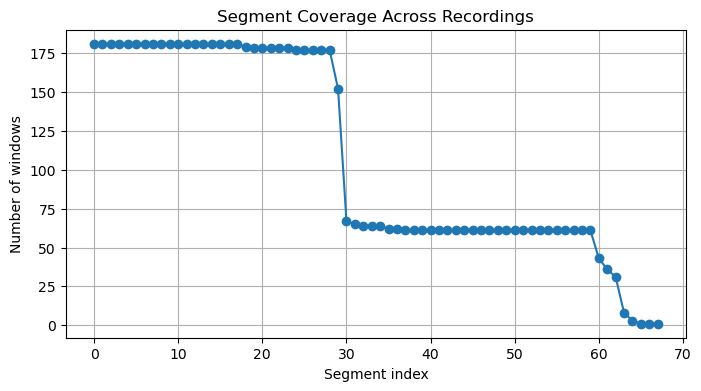

In [42]:
segment_counts = seg_df_10["segment_idx"].value_counts().sort_index()

plt.figure(figsize=(8,4))
segment_counts.plot(marker="o")
plt.xlabel("Segment index")
plt.ylabel("Number of windows")
plt.title("Segment Coverage Across Recordings")
plt.grid(True)
plt.show()

The segment coverage plot shows that earlier segment indices have the most stable counts. Later segment indices have fewer samples because not all recordings are equally long. For this reason, the ablation analysis focuses on the better-covered early range.

1. stable region 
    - segment 0 -> 28 
    - ~180 samples per segment 
    - most reliable region

2. drop off region
    - around 29-30
    - sudden drop from ~ 180 -> ~65

3. Plateau
    - ~30 -> ~58
    - ~60 samples per segment 
    - medium reliability

4. Collapse region 
    - ~60+ 
    - Rapid drop near 0
    - noisy 
    - underepresented


Approach: restrict ablation range to stable region.

In [43]:
def run_temporal_ablation(
    X_seg,
    y_seg,
    groups_seg,
    seg_df,
    model,
    cv,
    valid_segments=None
):
    """
    Remove one segment index at a time and evaluate the change in performance.
    
    Parameters
    ----------
    X_seg: np.ndarray
        Segmented feature matrix
    y_seg: np.ndarray
        Segmented target vector
    groups_seg: np.ndarray
        Segmented group labels
    seg_df: pd.DataFrame
        DataFrame containing segment information
    model: sklearn estimator
        The machine learning model to evaluate
    gkf: sklearn cross-validator
        Group k-fold cross-validator
    valid_segments: list, or None
        List of valid segment indices to consider

    Returns
    -------
    baseline_ablation_df: pd.DataFrame
        DataFrame containing baseline performance metrics
    ablation_results_df: pd.DataFrame
        DataFrame containing ablation results for each removed segment
    """

    if "segment_idx" not in seg_df.columns:
        raise ValueError ("seg_df must contain a 'segment_idx' column")
    
    seg_df = seg_df.copy()
    seg_df["segment_idx"] = seg_df["segment_idx"].astype(int)

    baseline = cross_validate(
        model,
        X_seg,
        y_seg,
        groups=groups_seg,
        cv=cv,
        scoring=["accuracy", "f1", "roc_auc"]
    )

   
    baseline_acc = baseline["test_accuracy"].mean(),
    baseline_f1 =  baseline["test_f1"].mean(),
    baseline_auc = baseline["test_roc_auc"].mean()
    

    if valid_segments is None:
        valid_segments = sorted(seg_df["segment_idx"].unique())

    results = []

    for seg_idx in valid_segments:
        keep_mask = seg_df["segment_idx"].to_numpy() != seg_idx

        X_ablate = X_seg[keep_mask]
        y_ablate = y_seg[keep_mask]
        groups_ablate = groups_seg[keep_mask]

        scores = cross_validate(
            model,
            X_ablate,
            y_ablate,
            groups=groups_ablate,   
            cv=cv,
            scoring=["accuracy", "f1", "roc_auc"]
        )
        
        acc = scores["test_accuracy"].mean()
        f1 = scores["test_f1"].mean()
        auc = scores["test_roc_auc"].mean()

        results.append({
            "ablated_segment": seg_idx,
            "n_samples_remaining": X_ablate.shape[0],
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc,
            "delta_accuracy": acc - baseline_acc,
            "delta_f1": f1 - baseline_f1,
            "delta_roc_auc": auc - baseline_auc
        })

    baseline_df = pd.DataFrame([{
        "ablated_segment": "baseline",
        "n_samples_remaining": X_seg.shape[0],
        "accuracy": baseline_acc,
        "f1": baseline_f1,
        "roc_auc": baseline_auc,
        "delta_accuracy": 0.0,
        "delta_f1": 0.0,
        "delta_roc_auc": 0.0
    }])

    ablation_df = pd.DataFrame(results)

    return baseline_df, ablation_df

In [45]:
VALID_SEGMENTS = range(0,30)

baseline_ablation_df, ablation_results_df = run_temporal_ablation(
    X_seg_10,
    y_seg_10,
    groups_seg_10,
    seg_df_10,
    model=models["SVM RBF"],
    cv=gkf,
    valid_segments=VALID_SEGMENTS
)

ablation_results_df.head()

,ablated_segment,n_samples_remaining,accuracy,f1,roc_auc,delta_accuracy,delta_f1,delta_roc_auc
0,0,7158,0.825841,0.842266,0.905412,[-0.0013897422981976604],[-0.0021997703686277292],-0.002703
1,1,7158,0.825866,0.842548,0.904435,[-0.0013648081445213345],[-0.001917569233323979],-0.003680
2,2,7158,0.824530,0.841551,0.906052,[-0.0027008672253011623],[-0.002914450777424249],-0.002064
3,3,7158,0.823974,0.840201,0.905304,[-0.003257480493761733],[-0.004264793636172826],-0.002812
4,4,7158,0.822984,0.839972,0.904258,[-0.004247293652210105],[-0.004493240722821978],-0.003857


In [46]:
ablation_results_df["delta_accuracy"] = ablation_results_df["delta_accuracy"].apply(
    lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x
)

ablation_results_df["delta_f1"] = ablation_results_df["delta_f1"].apply(
    lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x
)

ablation_results_df["delta_roc_auc"] = ablation_results_df["delta_roc_auc"].apply(
    lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x  
)


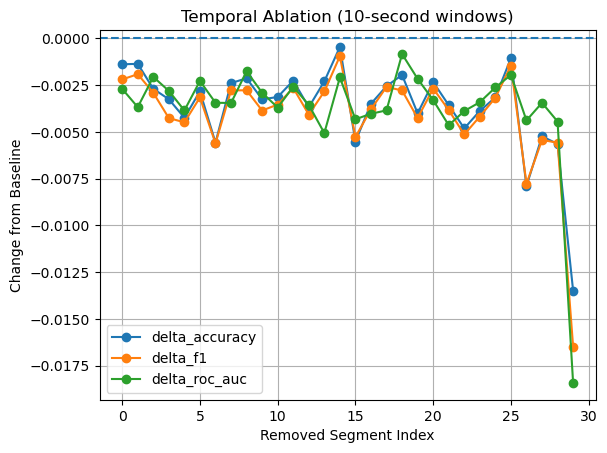

In [47]:
ablation_results_df.plot(
    x="ablated_segment",
    y=["delta_accuracy", "delta_f1", "delta_roc_auc"],
    marker='o'
)

plt.axhline(0, linestyle="--")
plt.xlabel("Removed Segment Index")
plt.ylabel("Change from Baseline")
plt.title("Temporal Ablation (10-second windows)")
plt.grid(True)
plt.show()

1. Overall pattern 
    - almost all segments (0-25) -> small drops 
    - no signle segment causes a large collapse

    Signal is distributed across time, not localized

2. Early segments (0-10)
    - consistent small negative impact
    - no sharp dips

    Early signal matters, but not uniquely 

3. Mid segments (10-25)
    - similar magnitude drops
    - slight variability

    Middle of recordings carries comparable information 

4. Late segments( ~26-29)
    - large drops, but not a biological signal - earlier plot shows very few samples in these segments, removing them disproportionately changes dataset balance 

    Larger performance drops observed in later segments are likely due to reduced sample size rather than meaningful temporal importance. 

Overall, temporal ablation analysis showed that removing individual time segments resulted in small but consistent decreases in model performance across most of the recording. This indicates that informative EEG features are distributed throughout the signal rather than concentrated in a specific time window. While larger performance drops were observed in later segments, these are likely driven by reduced sample coverage rather than true signal importance. 

## 8. Feature-Space Exploration: PCA, UMAP, and GMM

The next exploratory step asks whether the feature space itself shows structure. PCA gives a linear projection, while UMAP gives a nonlinear projection. GMM is then used to test whether unsupervised clusters roughly alogn with labels. 

Explained variance: [0.53077155 0.23748297]
Total explained variance: 0.7682545245377299


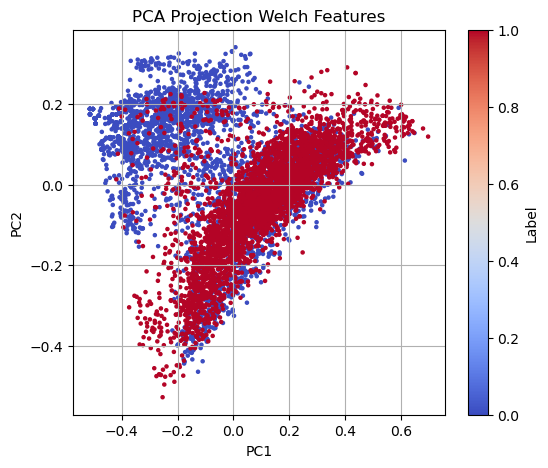

In [48]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_seg_10)

print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())


plt.figure(figsize=(6,5))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_seg_10,
    cmap="coolwarm",
    s=5
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection Welch Features")
plt.colorbar(label="Label")
plt.grid(True)
plt.show()

### Interpretation 

PCA shows that while there is some separation between MDD and healthy subjects along the principal components, the classes are highly overlapping. This indicates that the extracted EEG features contain meaningful signal, but the separation is not linearly clean, which motivates the use of non-linear models such as SVM. 

c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


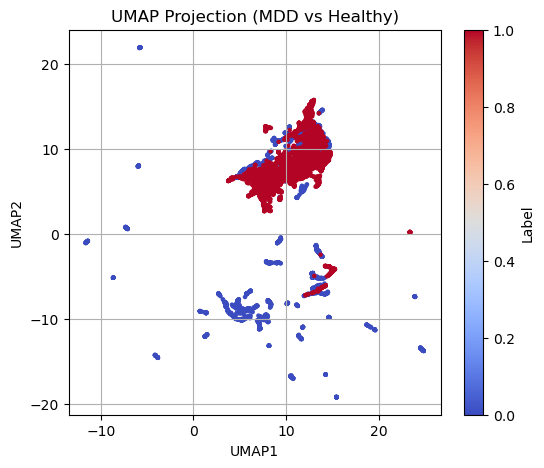

In [14]:
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_seg_10)

# plot UMAP results 
plt.figure(figsize=(6,5))
plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=y_seg_10,
    cmap="coolwarm",
    s=5
)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2") 
plt.title("UMAP Projection (MDD vs Healthy)")
plt.colorbar(label="Label") 
plt.grid(True)
plt.show()

### Interpretation:

UMAP reveals that MDD samples tend to cluster more tightly in feature space, while healthy samples are more dispersed. This suggests that depression-related EEG features may be more consistent across subjects, whereas healthy EEG exhibits greater variability.

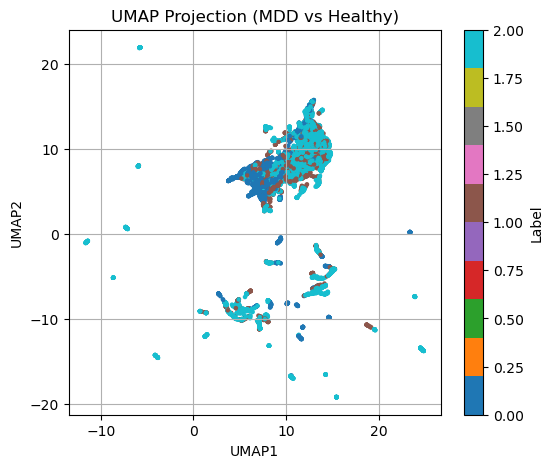

In [16]:
# color by condition code 
plt.figure(figsize=(6,5))

plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=seg_df_10["condition"].map({
        "eyesClosed": 0,
        "eyesOpen": 1,
        "P300": 2
    }),
    cmap="tab10",
    s=5
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2") 
plt.title("UMAP Projection (MDD vs Healthy)")
plt.colorbar(label="Label") 
plt.grid(True)
plt.show()

### Interpretation:

The PCA projection shows limited linear separation. UMAP shows stronger nonlinear structure, but condition labels are mixed across the embedding. This suggest that clustering is not simply being driven by recording condition. 



GMM clustering consistency: 0.790971495335393


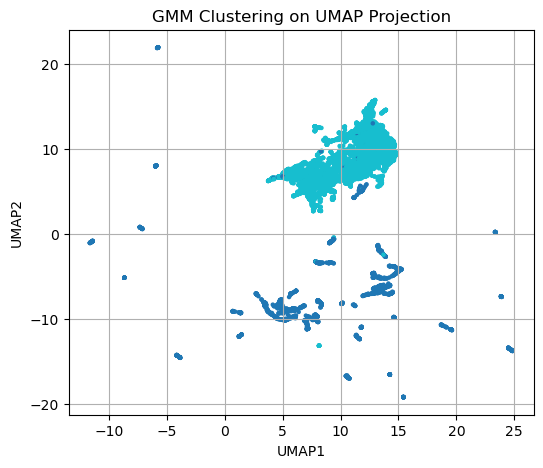

In [18]:
def clustering_accuracy(y_true, y_pred):
    """"
    Estimate clustering consistency by matching each true class to its dominant predicted cluster.

    This is not a supervised classification accuracy. It is a quick interpretability check because
    unsupervised cluster labels are arbitrary.
    """
    accs = []

    for true_label in np.unique(y_true):
        mask = (y_true == true_label)
        dominant_cluster = Counter(y_pred[mask]).most_common(1)[0][0]
        accs.append(np.mean(y_pred[mask] == dominant_cluster))
        
    return np.mean(accs)

gmm = GaussianMixture(n_components=2, random_state=RANDOM_STATE)
gmm_labels = gmm.fit_predict(X_seg_10)

print("GMM clustering consistency:", clustering_accuracy(y_seg_10, gmm_labels))

plt.figure(figsize=(6,5))
plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=gmm_labels,
    cmap="tab10",
    s=5
)

plt.title("GMM Clustering on UMAP Projection")
plt.xlabel("UMAP1") 
plt.ylabel("UMAP2")
plt.grid(True)
plt.show()

### Interpretation 

Clustering accuracy: 0.790971495335393

Gaussian Mixture Modeling achieved approximately 0.79 clustering accuracy, indicating that the extracted EEG features naturally form structure that closely aligns with diagnostic labels, even without supervision. 

Overall:

EEG-derived band power features contain meaningful, structured information about depression that is not linearly separable but becomes evident in nonlinear representations. This structure is strong enough that unsupervised clustering can approximate diagnostic labels with high accuracy. 

## 9. Raw EEG Comparison   

Welch features summarize frequency content. To compare against less-engineered representation, the next section uses raw 10-second EEG windows.

The raw windows are evaluated in two ways:

1. Flattened raw signal + PCA + SVM
2. Raw signal deep-learning models

In [19]:
def build_raw_segmented_dataset(metadata_df, common_channels, window_sec=10.0):
    """ Build raw EEG windows without Welch feature extraction."""
    X_segments = []
    y_segments = []
    groups_segments = []
    condition_segments = []
    recording_segments = []
    segment_indices = []
        
    for _, row in metadata_df.iterrows():
        raw = mne.io.read_raw_edf(row["filepath"], preload=True, verbose=False)
        raw.pick(common_channels)

        epochs = mne.make_fixed_length_epochs(
            raw,
            duration=window_sec,
            preload=True,
            overlap=0.0,
            verbose=False
        )

        epoch_data = epochs.get_data() 

        for i, segment in enumerate(epoch_data):
            X_segments.append(segment)
            y_segments.append(row["label"])
            groups_segments.append(row["patient_id"])
            condition_segments.append(row["condition"])
            recording_segments.append(f"{row['recording_id']}_seg{i}")
            segment_indices.append(i)

    X_segments = np.stack(X_segments)
    y_segments = np.array(y_segments)
    groups_segments = np.array(groups_segments)

    segmented_raw_df = pd.DataFrame({
        "recording_segment": recording_segments,
        "patient_id": groups_segments,
        "label": y_segments,
        "condition": condition_segments,
        "segment_idx": segment_indices
    })

    return X_segments, y_segments, groups_segments, segmented_raw_df

In [20]:
# This cell can take time becuase it reads all EDF files again. 
X_raw_10, y_raw_10, groups_raw_10, raw_seg_df_10 = build_raw_segmented_dataset(
    metadata_df,
    COMMON_CHANNELS,
    window_sec=10.0
)

print("Raw segmented X shape:", X_raw_10.shape)
print("Raw segmented y shape:", y_raw_10.shape) 
print("Unique patients:", len(np.unique(groups_raw_10)))
print(raw_seg_df_10.head())

Raw segmented X shape: (7339, 20, 2560)
Raw segmented y shape: (7339,)
Unique patients: 64
                  recording_segment patient_id  label   condition  segment_idx
0  sub-HS1_task-eyesClosed_eeg_seg0    sub-HS1      0  eyesClosed            0
1  sub-HS1_task-eyesClosed_eeg_seg1    sub-HS1      0  eyesClosed            1
2  sub-HS1_task-eyesClosed_eeg_seg2    sub-HS1      0  eyesClosed            2
3  sub-HS1_task-eyesClosed_eeg_seg3    sub-HS1      0  eyesClosed            3
4  sub-HS1_task-eyesClosed_eeg_seg4    sub-HS1      0  eyesClosed            4


In [23]:
# flatten raw segments for modeling

X_raw_10_flat = X_raw_10.reshape(X_raw_10.shape[0], -1)

pipeline_raw_pca_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50, random_state=42)),
    ("clf", SVC(kernel="rbf", probability=True, random_state=42))
])

raw_pca_results = evaluate_sklearn_model(
    pipeline_raw_pca_svm,
    X_raw_10_flat,
    y_raw_10,
    groups_raw_10
)

raw_pca_results

{'accuracy': 0.7028909271537475,
 'f1': 0.7784027681001386,
 'roc-auc': 0.807439685496161}

### Interpretation

- Raw signal performs significantly worse 
- Accuracy drop: ~ 12-13%
- ROC-AUC drop: ~0.10

- Welch's method is NOT just compressing the data, it is extracting useful, stable signal. 

Raw EEG:
- very noise
- high dimensional (51,200)
- cotains irrelevant fluctuations

Even with PCA:
- signal gets mixed with noise
- discriminative features are harder to isolate 

Applying Welch's method improves model performance by extracting stable frequency-domain features and reducing noise, while raw EEG signals even after PCA are less effective for classification. 

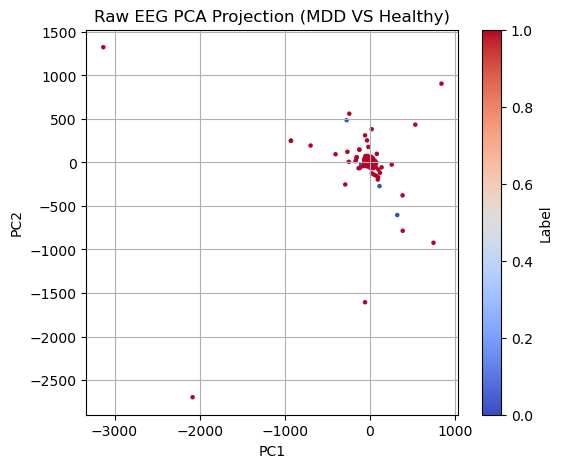

In [30]:
scaler_raw = StandardScaler()
X_raw_10_scaled = scaler_raw.fit_transform(X_raw_10_flat)

# PCA
pca_raw = PCA(n_components=50, random_state=42)
X_raw_10_pca = pca_raw.fit_transform(X_raw_10_scaled)

# plot PCA
plt.figure(figsize=(6,5))
plt.scatter(
    X_raw_10_pca[:,0],
    X_raw_10_pca[:,1],
    c=y_raw_10,
    cmap="coolwarm",
    s=5
)

plt.title("Raw EEG PCA Projection (MDD VS Healthy)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Label")
plt.grid(True)
plt.show()

- Huge spread
- Almost no separation
- Outliers dominating variance

c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


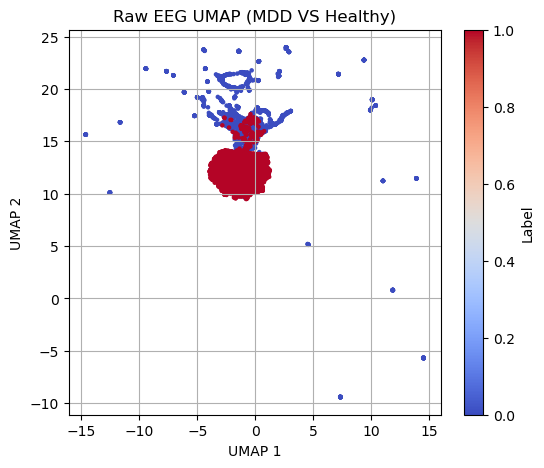

In [28]:
umap_raw_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_raw_umap = umap_raw_model.fit_transform(X_raw_10_pca)

plt.figure(figsize=(6,5))
plt.scatter(
    X_raw_umap[:,0],
    X_raw_umap[:,1],
    c=y_raw_10,
    cmap="coolwarm",
    s=5
)

plt.title("Raw EEG UMAP (MDD VS Healthy)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(label="Label")
plt.grid(True)
plt.show()

Two clear regions:
    - bottom dense cluster (mostly red)
    - upper scattered region (mostly blue)

Raw EGG contains structure, but it is not easily separable using simple probablistic clustering. Nonlinear embedding (UMAP) reveals this structure, and deep learning models (CNN) can succesfully exploit it. 

## 10. RAW EEG for Deep Learning 

CNN-style can learn local temporal patterns directly from raw EEG windows. Before training , each segment is z-scored channel-wise to reduce baseline and amplitude differences across recordings. 

In [26]:
print(X_raw_10.shape)
print(y_raw_10.shape)
print(np.unique(y_raw_10))

(7339, 20, 2560)
(7339,)
[0 1]


In [31]:
def zscore_segments(X):
    """
    Z-score each channel within each sample. 
    Input shape:
    (n_samples, n_channels, n_timepoints)
    """

    mean = X.mean(axis=2, keepdims=True)
    std = X.std(axis=2, keepdims=True)
    std[std == 0] = 1.0
    return (X - mean) / std 

X_raw_10_z = zscore_segments(X_raw_10)
print(X_raw_10_z.shape)

# Keras Conv1D expects shape: (samples, timepoints, channels)
X_cnn = np.transpose(X_raw_10_z, (0,2,1))
print("CNN input shape:", X_cnn.shape)

(7339, 20, 2560)
CNN input shape: (7339, 2560, 20)


In [30]:
def build_cnn_model(input_shape):
    model = Sequential([
        Conv1D(32, kernel_size=7, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),

        Conv1D(64, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),

        Conv1D(128, kernel_size=3, activation='relu'),
        GlobalAveragePooling1D(),

        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')

    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=["accuracy"]
    )

    return model

In [38]:
# GroupKFold evaluation 

def evaluate_cnn_groupkfold(X, y, groups, n_splits=5, epochs=10, batch_size=32):
    gkf = GroupKFold(n_splits=n_splits)

    acc_scores = []
    f1_scores = []
    auc_scores = []

    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):
        print(f"\n===Fold {fold} ===")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = build_cnn_model(input_shape=X.shape[1:])

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, 
            y_train, 
            validation_split=0.2,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1,
            callbacks=[early_stop]
        )

        y_prob = model.predict(X_test).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        acc_scores.append(acc)
        f1_scores.append(f1)
        auc_scores.append(auc)

        fold_results.append({
            "fold": fold,
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc
        })

        print(f"Fold {fold} accuracy: {acc:.4f}")
        print(f"Fold {fold} F1: {f1:.4f}")
        print(f"Fold {fold} ROC-AUC: {auc:.4f}")

    summary = {
        "accuracy": np.mean(acc_scores),
        "f1": np.mean(f1_scores),
        "roc_auc": np.mean(auc_scores),
        "fold_results": pd.DataFrame(fold_results)
}

    return summary 

### Run CNN 

In [39]:
cnn_results = evaluate_cnn_groupkfold(
    X_cnn,
    y_raw_10,
    groups_raw_10,
    n_splits=5,
    epochs=10,
    batch_size=32
)

print("\nCNN mean accuracy:", cnn_results["accuracy"])
print("CNN mean F1:", cnn_results["f1"])
print("CNN mean ROC-AUC:", cnn_results["roc_auc"])
cnn_results["fold_results"]


===Fold 1 ===


c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 87s 147ms/step - accuracy: 0.8133 - loss: 0.3764 - val_accuracy: 0.8419 - val_loss: 1.9652
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.9076 - loss: 0.2097 - val_accuracy: 0.8132 - val_loss: 2.2648
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.9395 - loss: 0.1474 - val_accuracy: 0.8428 - val_loss: 1.8179
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 138ms/step - accuracy: 0.9457 - loss: 0.1322 - val_accuracy: 0.7498 - val_loss: 3.4841
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - accuracy: 0.9632 - loss: 0.0957 - val_accuracy: 0.7946 - val_loss: 3.1844
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.9717 - loss: 0.0820 - val_accuracy: 0.7701 - val_loss: 3.1424
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step
Fold 1 accuracy: 0.9509
Fold 1 F1: 0.9527
Fold 1 ROC-AUC: 0.9885

===Fold 2 ===


c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 23s 136ms/step - accuracy: 0.8302 - loss: 0.3456 - val_accuracy: 0.8439 - val_loss: 2.2767
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 24s 160ms/step - accuracy: 0.9356 - loss: 0.1570 - val_accuracy: 0.7218 - val_loss: 3.7203
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 148ms/step - accuracy: 0.9627 - loss: 0.0954 - val_accuracy: 0.7739 - val_loss: 4.3345
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - accuracy: 0.9744 - loss: 0.0711 - val_accuracy: 0.8311 - val_loss: 4.2913
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step
Fold 2 accuracy: 0.8621
Fold 2 F1: 0.8658
Fold 2 ROC-AUC: 0.9503

===Fold 3 ===


...

c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 137ms/step - accuracy: 0.8320 - loss: 0.3302 - val_accuracy: 0.5512 - val_loss: 2.5945
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - accuracy: 0.9086 - loss: 0.2096 - val_accuracy: 0.7841 - val_loss: 2.3999
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - accuracy: 0.9398 - loss: 0.1450 - val_accuracy: 0.8038 - val_loss: 3.7789
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - accuracy: 0.9456 - loss: 0.1309 - val_accuracy: 0.7935 - val_loss: 3.8154
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 143ms/step - accuracy: 0.9603 - loss: 0.0988 - val_accuracy: 0.7935 - val_loss: 3.6046
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step
Fold 4 accuracy: 0.9082
Fold 4 F1: 0.9174
Fold 4 ROC-AUC: 0.9817

===Fold 5 ===


c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 23s 138ms/step - accuracy: 0.8428 - loss: 0.3191 - val_accuracy: 0.7376 - val_loss: 1.3577
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - accuracy: 0.9297 - loss: 0.1713 - val_accuracy: 0.7206 - val_loss: 2.0260
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 132ms/step - accuracy: 0.9548 - loss: 0.1146 - val_accuracy: 0.7998 - val_loss: 1.4304
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - accuracy: 0.9621 - loss: 0.0973 - val_accuracy: 0.8416 - val_loss: 1.4819
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
Fold 5 accuracy: 0.8510
Fold 5 F1: 0.8304
Fold 5 ROC-AUC: 0.8655

CNN mean accuracy: 0.8724763162871685
CNN mean F1: 0.8813652515589686
CNN mean ROC-AUC: 0.9206958912268846


,fold,accuracy,f1,roc_auc
0,1,0.950912,0.952703,0.988532
1,2,0.862069,0.865789,0.950318
2,3,0.790148,0.840595,0.817465
3,4,0.908232,0.917375,0.981660
4,5,0.851020,0.830364,0.865504


In [41]:
comparison_df = pd.DataFrame([
    {
        "method": "Welch + SVM (10 sec)",
        "accuracy": 0.827231,
        "f1": 0.844465,
        "roc_auc": 0.908115
    },
    {
        "method": "Raw + PCA + SVM (10 sec)",
        "accuracy": 0.702891,
        "f1": 0.778403,
        "roc_auc": 0.807440
    },
    {
        "method": "Raw + CNN (10 sec)",
        "accuracy": cnn_results["accuracy"],
        "f1": cnn_results["f1"],
        "roc_auc": cnn_results["roc_auc"]
    }
])

comparison_df

,method,accuracy,f1,roc_auc
0,Welch + SVM (10 sec),0.827231,0.844465,0.908115
1,Raw + PCA + SVM (10 sec),0.702891,0.778403,0.807440
2,Raw + CNN (10 sec),0.872476,0.881365,0.920696


CNN on raw EEG outperfoms both classical and raw features and Welch-based features.

- CNN extracts structure, achieved ~0.92 ROC-AUC (highest overall)
- Potperfomed both Welch + SVM and Raw + PCA + SVM
- indicates raw EEG contains rich temporal information
- deep learning captutes structure missed by classical models
- some variability across folds
- Fold 1: 0.99 ROC-AUC
- Fold 3: 0.82 ROC-AUC
- Large spread 

possible reasons for variability: 
- subject variability
- class imbalance per fold
- CNN sensitivity to training split 


Interpretation:

While classical models performed best on Welch-derived features, CNNS trained directly on raw EEG segments achieved higher overall performance, suggesting that deep learning models can extract meaningful temporal structure that is not captured by handcrafted spectral features. However, performance variability across folds indicates sensitivity to subject-level differences.


### LSTM

In [42]:
from tensorflow.keras.layers import LSTM

In [47]:
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=False),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model 

In [48]:
def evaluate_lstm_groupkfold(X, y, groups, n_splits=5, epochs=10, batch_size=32):
    gkf = GroupKFold(n_splits=n_splits)

    acc_scores = []
    f1_scores = []
    auc_scores = []

    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):
        print(f"\n===Fold {fold} ===")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = build_lstm_model(input_shape=X.shape[1:])

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, 
            y_train, 
            validation_split=0.2,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1,
            callbacks=[early_stop]
        )

        y_prob = model.predict(X_test).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        acc_scores.append(acc)
        f1_scores.append(f1)
        auc_scores.append(auc)

        fold_results.append({
            "fold": fold,
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc
        })

        print(f"Fold {fold} accuracy: {acc:.4f}")
        print(f"Fold {fold} F1: {f1:.4f}")
        print(f"Fold {fold} ROC-AUC: {auc:.4f}")

    summary = {
        "accuracy": np.mean(acc_scores),
        "f1": np.mean(f1_scores),
        "roc_auc": np.mean(auc_scores),
        "fold_results": pd.DataFrame(fold_results)
}

    return summary 

In [49]:
lstm_results = evaluate_lstm_groupkfold(
    X_cnn,
    y_raw_10,
    groups_raw_10,
    n_splits=5,
    epochs=10,
    batch_size=32
)

print("\nLSTM mean accuracy:", lstm_results["accuracy"])
print("LSTM mean F1:", lstm_results["f1"])
print("LSTM mean ROC-AUC:", lstm_results["roc_auc"])
lstm_results["fold_results"]


===Fold 1 ===


c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.7070 - loss: 0.5551 - val_accuracy: 0.8588 - val_loss: 0.5503
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.8070 - loss: 0.4304 - val_accuracy: 0.9620 - val_loss: 0.4176
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.8114 - loss: 0.4268 - val_accuracy: 0.8952 - val_loss: 0.5137
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.7973 - loss: 0.4378 - val_accuracy: 0.8774 - val_loss: 0.6104
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.7856 - loss: 0.4260 - val_accuracy: 0.8740 - val_loss: 0.5980
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 436ms/step
Fold 1 accuracy: 0.7272
Fold 1 F1: 0.7833
Fold 1 ROC-AUC: 0.7925

===Fold 2 ===


c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.6866 - loss: 0.5659 - val_accuracy: 0.4548 - val_loss: 1.7863
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.7101 - loss: 0.5256 - val_accuracy: 0.9599 - val_loss: 0.6088
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.7278 - loss: 0.4911 - val_accuracy: 0.9189 - val_loss: 0.5780
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.7912 - loss: 0.4178 - val_accuracy: 0.9130 - val_loss: 0.6712
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.8163 - loss: 0.3861 - val_accuracy: 0.9027 - val_loss: 0.6861
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.8087 - loss: 0.4436 - val_accuracy: 0.6800 - val_loss: 1.0768
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 437ms/step
Fold 2 accuracy: 0.8147
Fold 2 F1: 0.8290
Fold 2 ROC-AUC: 0.8605

===Fold 3 ===


...

c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.7144 - loss: 0.5241 - val_accuracy: 0.8200 - val_loss: 0.6847
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.7974 - loss: 0.4106 - val_accuracy: 0.8328 - val_loss: 0.6557
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.8109 - loss: 0.3819 - val_accuracy: 0.7952 - val_loss: 1.0243
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.8169 - loss: 0.3785 - val_accuracy: 0.9334 - val_loss: 0.6167
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.8190 - loss: 0.3784 - val_accuracy: 0.8831 - val_loss: 0.6764
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.8348 - loss: 0.3559 - val_accuracy: 0.7756 - val_loss: 0.9521
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.8158 - loss: 0.3820 - val_accuracy: 0.9010 - val_loss: 0.7753
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 386ms/step
Fold 4 accuracy: 0.8462
Fold 4 F1: 0.8715
Fold 4 ROC-AU

c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.7355 - loss: 0.5052 - val_accuracy: 0.8101 - val_loss: 1.0914
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.8239 - loss: 0.4026 - val_accuracy: 0.8262 - val_loss: 0.9609
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.8349 - loss: 0.3705 - val_accuracy: 0.8450 - val_loss: 1.0121
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.8520 - loss: 0.3459 - val_accuracy: 0.7368 - val_loss: 1.1828
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.8296 - loss: 0.3744 - val_accuracy: 0.7487 - val_loss: 0.8163
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.8166 - loss: 0.4002 - val_accuracy: 0.8049 - val_loss: 1.0634
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.8443 - loss: 0.3455 - val_accuracy: 0.6985 - val_loss: 1.4022
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.8464 - loss: 0.3495 - val_accu

,fold,accuracy,f1,roc_auc
0,1,0.727209,0.783287,0.792490
1,2,0.814740,0.828964,0.860482
2,3,0.817814,0.859081,0.812402
3,4,0.846154,0.871477,0.875958
4,5,0.725170,0.753959,0.774404


In [51]:
comparison_df = pd.DataFrame([
    {
        "method": "Welch + SVM (10 sec)",
        "accuracy": 0.827231,
        "f1": 0.844465,
        "roc_auc": 0.908115
    },
    {
        "method": "Raw + PCA + SVM (10 sec)",
        "accuracy": 0.702891,
        "f1": 0.778403,
        "roc_auc": 0.807440
    },
    {
        "method": "Raw + CNN (10 sec)",
        "accuracy": cnn_results["accuracy"],
        "f1": cnn_results["f1"],
        "roc_auc": cnn_results["roc_auc"]
    },
    {
         "method": "Raw + LSTM (10 sec)",
        "accuracy": lstm_results["accuracy"],
        "f1": lstm_results["f1"],
        "roc_auc": lstm_results["roc_auc"]
    }
])

comparison_df

,method,accuracy,f1,roc_auc
0,Welch + SVM (10 sec),0.827231,0.844465,0.908115
1,Raw + PCA + SVM (10 sec),0.702891,0.778403,0.807440
2,Raw + CNN (10 sec),0.872476,0.881365,0.920696
3,Raw + LSTM (10 sec),0.786217,0.819354,0.823147


## CNN + LSTM

In [1]:
## CNN + LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam


2026-04-24 00:29:35.225871: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [14]:
def build_cnn_lstm_model(input_shape):
    model = Sequential([
        # CNN feature extractor
        Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(filters=128, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # LSTM for temporal modeling
        LSTM(64, return_sequences=False),
        Dropout(0.3),

        # classifier head
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
def evaluate_cnn_lstm_groupkfold(X, y, groups, n_splits=5, epochs=10, batch_size=32):

    gkf = GroupKFold(n_splits=n_splits)

    acc_scores, f1_scores, auc_scores = [], [], []
    fold_results = []
    histories = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):

        print(f"\n=== Fold {fold} ===")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = build_cnn_lstm_model(input_shape=X.shape[1:])

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            validation_split=0.2,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1,
            callbacks=[early_stop]
        )

        histories.append(history.history)

        y_prob = model.predict(X_test).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        acc_scores.append(acc)
        f1_scores.append(f1)
        auc_scores.append(auc)

        fold_results.append({
            "fold": fold,
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc
        })

        print(f"Acc: {acc:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")

    return {
        "accuracy": np.mean(acc_scores),
        "f1": np.mean(f1_scores),
        "roc_auc": np.mean(auc_scores),
        "fold_results": pd.DataFrame(fold_results),
        "histories": histories
    }


In [16]:
cnn_lstm_results = evaluate_cnn_lstm_groupkfold(
    X_cnn,
    y_raw_10,
    groups_raw_10,
    n_splits=5,
    epochs=10,
    batch_size=32
)


=== Fold 1 ===
45/45 [==============================] - 22s 467ms/step
Acc: 0.874 | F1: 0.902 | AUC: 0.920

=== Fold 2 ===
47/47 [==============================] - 10s 205ms/step
Acc: 0.957 | F1: 0.964 | AUC: 0.965

=== Fold 3 ===
47/47 [==============================] - 15s 308ms/step
Acc: 0.733 | F1: 0.754 | AUC: 0.824

=== Fold 4 ===
47/47 [==============================] - 16s 307ms/step
Acc: 0.717 | F1: 0.696 | AUC: 0.769

=== Fold 5 ===
46/46 [==============================] - 28s 598ms/step
Acc: 0.773 | F1: 0.832 | AUC: 0.797


In [19]:
comparison_df = pd.DataFrame([
    {
        "method": "Welch + SVM (10 sec)",
        "accuracy": 0.827231,
        "f1": 0.844465,
        "roc_auc": 0.908115
    },
    {
        "method": "Raw + PCA + SVM (10 sec)",
        "accuracy": 0.702891,
        "f1": 0.778403,
        "roc_auc": 0.807440
    },
    {
        "method": "Raw + CNN (10 sec)",
        "accuracy": 0.872476,
        "f1": 0.881365,
        "roc_auc": 0.920696
    },
    {
        "method": "Raw + LSTM (10 sec)",
        "accuracy": 0.786217,
        "f1": 0.819354,
        "roc_auc": 	0.823147
    },
    {
        "method": "Raw + CNN-LSTM (10 sec)",
        "accuracy": cnn_lstm_results["accuracy"],
        "f1": cnn_lstm_results["f1"],
        "roc_auc": cnn_lstm_results["roc_auc"]
    }
])

comparison_df

,method,accuracy,f1,roc_auc
0,Welch + SVM (10 sec),0.827231,0.844465,0.908115
1,Raw + PCA + SVM (10 sec),0.702891,0.778403,0.807440
2,Raw + CNN (10 sec),0.872476,0.881365,0.920696
3,Raw + LSTM (10 sec),0.786217,0.819354,0.823147
4,Raw + CNN-LSTM (10 sec),0.811083,0.829698,0.855132


Classical feature-based methods (Welch + SVM) and CNN-based deep learning achieved the strongest performance, while recurrent architectures did not provide additional benefit.

## CNN Limitation 1: Deeper CNN

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Dense, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam

def build_cnn_deeper(input_shape):

    model = Sequential([
        
        Conv1D(32, kernel_size=7, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        
        Conv1D(64, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        
        Conv1D(128, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # ===== (NEW DEPTH) =====
        Conv1D(256, kernel_size=3, activation='relu'),
        Dropout(0.3),

        
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [25]:
def run_cnn_deeper_groupkfold(X, y, groups, n_splits=5, epochs=10, batch_size=32):

    gkf = GroupKFold(n_splits=n_splits)

    acc_scores, f1_scores, auc_scores = [], [], []
    fold_results = []
    histories = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):

        print(f"\n=== Fold {fold} ===")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = build_cnn_deeper(input_shape=X.shape[1:])

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            validation_split=0.2,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1,
            callbacks=[early_stop]
        )

        histories.append(history.history)

        y_prob = model.predict(X_test).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        acc_scores.append(acc)
        f1_scores.append(f1)
        auc_scores.append(auc)

        fold_results.append({
            "fold": fold,
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc
        })

        print(f"Acc: {acc:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")

    return {
        "accuracy": np.mean(acc_scores),
        "f1": np.mean(f1_scores),
        "roc_auc": np.mean(auc_scores),
        "fold_results": pd.DataFrame(fold_results),
        "histories": histories
    }

In [26]:
cnn_deeper_results = run_cnn_deeper_groupkfold(
    X_cnn,
    y_raw_10,
    groups_raw_10,
    n_splits=5,
    epochs=10,
    batch_size=32
)


=== Fold 1 ===
Epoch 1/10
148/148 [==============================] - 27s 173ms/step - loss: 0.3168 - accuracy: 0.8461 - val_loss: 1.8551 - val_accuracy: 0.8377
Epoch 2/10
148/148 [==============================] - 30s 203ms/step - loss: 0.1834 - accuracy: 0.9195 - val_loss: 2.6624 - val_accuracy: 0.8428
Epoch 3/10
148/148 [==============================] - 29s 196ms/step - loss: 0.1148 - accuracy: 0.9567 - val_loss: 2.9193 - val_accuracy: 0.8157
Epoch 4/10
45/45 [==============================] - 2s 44ms/step
Acc: 0.964 | F1: 0.969 | AUC: 0.993

=== Fold 2 ===
Epoch 1/10
147/147 [==============================] - 26s 170ms/step - loss: 0.3539 - accuracy: 0.8264 - val_loss: 2.0387 - val_accuracy: 0.8072
Epoch 2/10
147/147 [==============================] - 25s 168ms/step - loss: 0.1894 - accuracy: 0.9228 - val_loss: 2.8028 - val_accuracy: 0.7253
Epoch 3/10
147/147 [==============================] - 27s 183ms/step - loss: 0.1426 - accuracy: 0.9435 - val_loss: 2.0186 - val_accuracy: 0.83

In [28]:
comparison_df = pd.DataFrame([
    {
        "method": "Welch + SVM (10 sec)",
        "accuracy": 0.827231,
        "f1": 0.844465,
        "roc_auc": 0.908115
    },
    {
        "method": "Raw + PCA + SVM (10 sec)",
        "accuracy": 0.702891,
        "f1": 0.778403,
        "roc_auc": 0.807440
    },
    {
        "method": "Raw + CNN (baseline)",
        "accuracy": 0.872476,
        "f1": 0.881365,
        "roc_auc": 0.920696
    },
    {
        "method": "Raw + LSTM",
        "accuracy": 0.786217,
        "f1": 0.819354,
        "roc_auc": 0.823147
    },
    {
        "method": "Raw + CNN-LSTM",
        "accuracy": 0.811083,
        "f1": 0.829698,
        "roc_auc": 0.855132
    },
    {
        "method": "Raw + Deep CNN",
        "accuracy": cnn_deeper_results["accuracy"],
        "f1": cnn_deeper_results["f1"],
        "roc_auc": cnn_deeper_results["roc_auc"]
    }
])

comparison_df

,method,accuracy,f1,roc_auc
0,Welch + SVM (10 sec),0.827231,0.844465,0.908115
1,Raw + PCA + SVM (10 sec),0.702891,0.778403,0.807440
2,Raw + CNN (baseline),0.872476,0.881365,0.920696
3,Raw + LSTM,0.786217,0.819354,0.823147
4,Raw + CNN-LSTM,0.811083,0.829698,0.855132
5,Raw + Deep CNN,0.880238,0.870826,0.925985


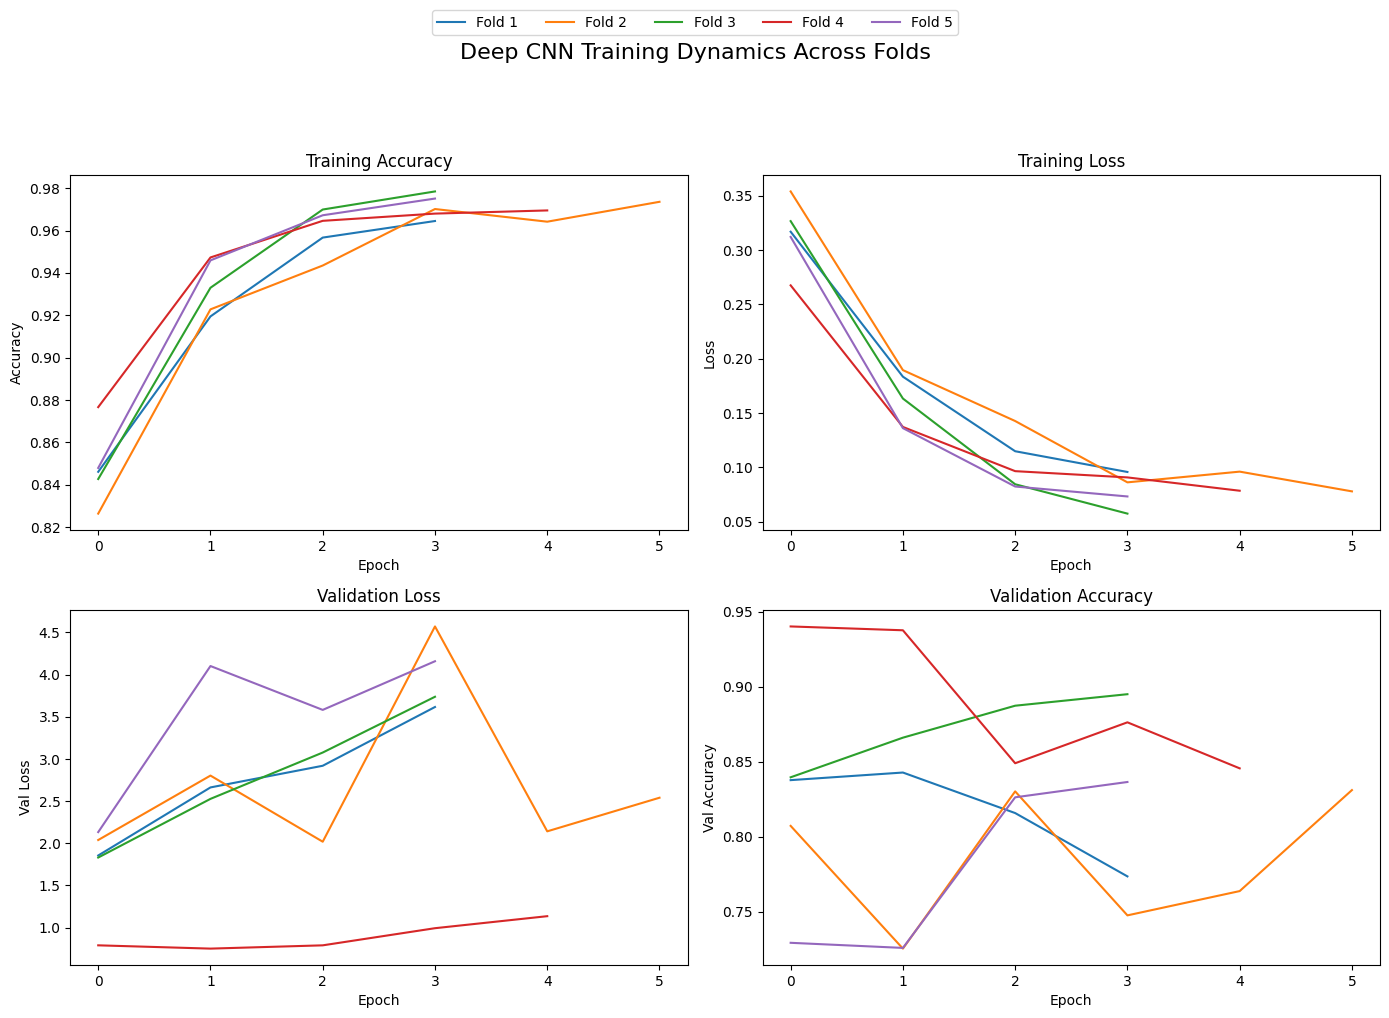

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ===== 1. Training Accuracy =====
for i, hist in enumerate(cnn_deeper_results["histories"]):
    axes[0, 0].plot(hist["accuracy"], label=f"Fold {i+1}")

axes[0, 0].set_title("Training Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")

# ===== 2. Training Loss =====
for i, hist in enumerate(cnn_deeper_results["histories"]):
    axes[0, 1].plot(hist["loss"], label=f"Fold {i+1}")

axes[0, 1].set_title("Training Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")

# ===== 3. Validation Loss =====
for i, hist in enumerate(cnn_deeper_results["histories"]):
    axes[1, 0].plot(hist["val_loss"], label=f"Fold {i+1}")

axes[1, 0].set_title("Validation Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Val Loss")

# ===== 4. Validation Accuracy =====
for i, hist in enumerate(cnn_deeper_results["histories"]):
    axes[1, 1].plot(hist["val_accuracy"], label=f"Fold {i+1}")

axes[1, 1].set_title("Validation Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Val Accuracy")

plt.suptitle("Deep CNN Training Dynamics Across Folds", fontsize=16)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

The Deep CNN demonstrates strong learning capacity across all folds, with training accuracy consistently reaching 0.96–0.98 and rapidly decreasing training loss, indicating effective feature extraction from EEG signals. However, validation performance exhibits substantial instability across subject-wise splits. While some folds achieve strong generalization performance (e.g., Fold 4 with validation accuracy ~0.94 and relatively low validation loss), other folds show degraded performance with significantly higher validation loss (up to ~4.5) and reduced accuracy.

This divergence between training and validation behavior suggests that although the model is highly expressive, it is sensitive to inter-subject variability inherent in EEG data. The inconsistent validation loss trends and fluctuating validation accuracy across folds indicate that improvements in training performance do not always translate to robust generalization. As a result, the Deep CNN provides high peak performance but lacks consistent stability across all subject partitions, highlighting a trade-off between model complexity and robustness in EEG classification tasks.

High validation loss and high validation accuracy variabilities

## CNN Limiation 2: Multi-scale CNN

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D
from tensorflow.keras.layers import GlobalAveragePooling1D, Concatenate
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_multiscale_cnn(input_shape):

    inputs = Input(shape=input_shape)

    # ===== Branch 1: small scale =====
    x1 = Conv1D(32, kernel_size=3, activation='relu', padding='same')(inputs)
    x1 = MaxPooling1D(2)(x1)

    # ===== Branch 2: medium scale =====
    x2 = Conv1D(32, kernel_size=5, activation='relu', padding='same')(inputs)
    x2 = MaxPooling1D(2)(x2)

    # ===== Branch 3: large scale =====
    x3 = Conv1D(32, kernel_size=9, activation='relu', padding='same')(inputs)
    x3 = MaxPooling1D(2)(x3)

    # ===== Merge =====
    merged = Concatenate()([x1, x2, x3])

    # Further feature extraction
    x = Conv1D(64, kernel_size=3, activation='relu')(merged)
    x = MaxPooling1D(2)(x)

    x = GlobalAveragePooling1D()(x)

    # Classifier
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [30]:
def run_multiscale_cnn_groupkfold(X, y, groups, n_splits=5, epochs=10, batch_size=32):

    gkf = GroupKFold(n_splits=n_splits)

    acc_scores, f1_scores, auc_scores = [], [], []
    fold_results = []
    histories = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):

        print(f"\n=== Fold {fold} ===")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]


        model = build_multiscale_cnn(input_shape=X.shape[1:])

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            validation_split=0.2,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1,
            callbacks=[early_stop]
        )

        histories.append(history.history)

        y_prob = model.predict(X_test).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        acc_scores.append(acc)
        f1_scores.append(f1)
        auc_scores.append(auc)

        fold_results.append({
            "fold": fold,
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc
        })

        print(f"Acc: {acc:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")

    return {
        "accuracy": np.mean(acc_scores),
        "f1": np.mean(f1_scores),
        "roc_auc": np.mean(auc_scores),
        "fold_results": pd.DataFrame(fold_results),
        "histories": histories
    }

In [31]:
multiscale_results = run_multiscale_cnn_groupkfold(
    X_cnn,
    y_raw_10,
    groups_raw_10,
    n_splits=5,
    epochs=10,
    batch_size=32
)


=== Fold 1 ===
Epoch 1/10
148/148 [==============================] - 20s 125ms/step - loss: 0.3740 - accuracy: 0.8091 - val_loss: 1.5901 - val_accuracy: 0.8276
Epoch 2/10
148/148 [==============================] - 17s 112ms/step - loss: 0.2269 - accuracy: 0.9011 - val_loss: 2.0971 - val_accuracy: 0.8259
Epoch 3/10
148/148 [==============================] - 17s 117ms/step - loss: 0.1375 - accuracy: 0.9444 - val_loss: 2.8501 - val_accuracy: 0.7498
Epoch 4/10
45/45 [==============================] - 2s 37ms/step
Acc: 0.946 | F1: 0.953 | AUC: 0.988

=== Fold 2 ===
Epoch 1/10
147/147 [==============================] - 19s 123ms/step - loss: 0.3622 - accuracy: 0.8178 - val_loss: 1.7955 - val_accuracy: 0.7065
Epoch 2/10
147/147 [==============================] - 17s 113ms/step - loss: 0.1997 - accuracy: 0.9168 - val_loss: 2.2316 - val_accuracy: 0.7765
Epoch 3/10
147/147 [==============================] - 15s 104ms/step - loss: 0.1555 - accuracy: 0.9343 - val_loss: 2.7579 - val_accuracy: 0.71

In [32]:
comparison_df = pd.DataFrame([
    {
        "method": "Welch + SVM (10 sec)",
        "accuracy": 0.827231,
        "f1": 0.844465,
        "roc_auc": 0.908115
    },
    {
        "method": "Raw + PCA + SVM (10 sec)",
        "accuracy": 0.702891,
        "f1": 0.778403,
        "roc_auc": 0.807440
    },
    {
        "method": "Raw + CNN (baseline)",
        "accuracy": 0.872476,
        "f1": 0.881365,
        "roc_auc": 0.920696
    },
    {
        "method": "Raw + LSTM",
        "accuracy": 0.786217,
        "f1": 0.819354,
        "roc_auc": 0.823147
    },
    {
        "method": "Raw + CNN-LSTM",
        "accuracy": 0.811083,
        "f1": 0.829698,
        "roc_auc": 0.855132
    },
    {
        "method": "Raw + Deep CNN",
        "accuracy": 0.880238,
        "f1": 0.870826,
        "roc_auc": 0.925985
    },
    {
        "method": "Raw + Multi-Scale CNN",
        "accuracy": multiscale_results["accuracy"],
        "f1": multiscale_results["f1"],
        "roc_auc": multiscale_results["roc_auc"]
    }
])
comparison_df

,method,accuracy,f1,roc_auc
0,Welch + SVM (10 sec),0.827231,0.844465,0.908115
1,Raw + PCA + SVM (10 sec),0.702891,0.778403,0.807440
2,Raw + CNN (baseline),0.872476,0.881365,0.920696
3,Raw + LSTM,0.786217,0.819354,0.823147
4,Raw + CNN-LSTM,0.811083,0.829698,0.855132
5,Raw + Deep CNN,0.880238,0.870826,0.925985
6,Raw + Multi-Scale CNN,0.872279,0.859736,0.924185


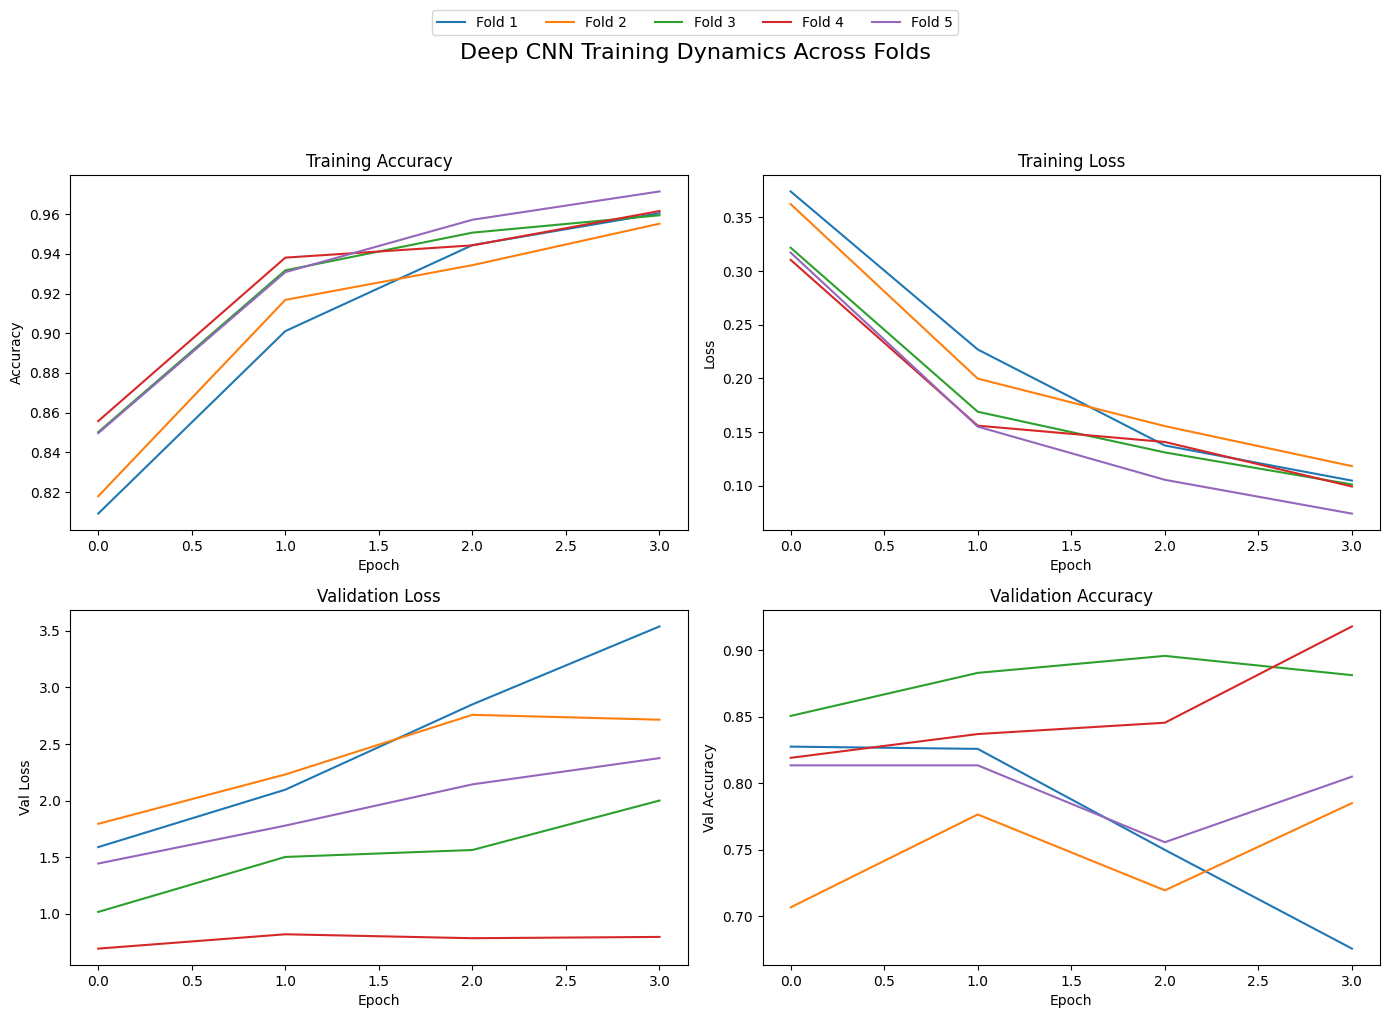

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ===== 1. Training Accuracy =====
for i, hist in enumerate(multiscale_results["histories"]):
    axes[0, 0].plot(hist["accuracy"], label=f"Fold {i+1}")

axes[0, 0].set_title("Training Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")

# ===== 2. Training Loss =====
for i, hist in enumerate(multiscale_results["histories"]):
    axes[0, 1].plot(hist["loss"], label=f"Fold {i+1}")

axes[0, 1].set_title("Training Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")

# ===== 3. Validation Loss =====
for i, hist in enumerate(multiscale_results["histories"]):
    axes[1, 0].plot(hist["val_loss"], label=f"Fold {i+1}")

axes[1, 0].set_title("Validation Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Val Loss")

# ===== 4. Validation Accuracy =====
for i, hist in enumerate(multiscale_results["histories"]):
    axes[1, 1].plot(hist["val_accuracy"], label=f"Fold {i+1}")

axes[1, 1].set_title("Validation Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Val Accuracy")

plt.suptitle("Deep CNN Training Dynamics Across Folds", fontsize=16)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

The Multi-Scale CNN demonstrates strong learning capacity, with training loss consistently decreasing and training accuracy reaching up to 0.97 across folds. However, validation performance exhibits considerable instability, with both validation loss and validation accuracy fluctuating significantly across epochs and folds. In several cases, validation loss increases substantially despite continued improvements in training accuracy, indicating overfitting to training distributions.

Although some folds achieve high validation accuracy, these improvements are not consistently reflected in final test performance, suggesting limited robustness across subject-wise splits. This discrepancy highlights the sensitivity of the model to inter-subject variability in EEG signals. Overall, the Multi-Scale CNN provides strong feature extraction capability but does not achieve stable generalization, indicating that multi-scale convolution alone is insufficient to fully address variability in EEG classification tasks.

## Final Interpretation 

The strongest overall performance came from CNN-based raw EEG models, especially the deeper CNN and baseline CNN. This suggests that raw EEG contains temporal structure that convolutional models can learn directly. 

However, the Welch + SVM model remains important because it proivides a stromg, interpretable classical baseline. It achieved high R0C-AUC while using only 80 spectral features per segment. 

The raw + PCA + SVM model performed substantially wprse, whowing that simply flattening raw EEG is not enough for classical ML. Either meaningful spectral feature extraction or deep-learning feature extraction is needed. 

The temporal ablation analysis did not show one dominant segment driving performance. This supports the interpretation that the classification signal is distributed across the recording rather than concentrated in a single time window.

